# Worksheet 5
## End-to-End CNN Model for Fruit Image Classification (Amazon Fruits Dataset)


In [8]:
import os

# ── Mount Google Drive ────────────────────────────────────────
from google.colab import drive
drive.mount('/content/drive')

# ── Direct folder paths (no unzipping needed) ─────────────────
base_dir  = '/content/drive/MyDrive/AI and machine Learning/week 5/FruitinAmazon'
train_dir = os.path.join(base_dir, 'train')
test_dir  = os.path.join(base_dir, 'test')

print('Train directory:', train_dir)
print('Test  directory:', test_dir)
print('Classes found  :', sorted(os.listdir(train_dir)))

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Train directory: /content/drive/MyDrive/AI and machine Learning/week 5/FruitinAmazon/train
Test  directory: /content/drive/MyDrive/AI and machine Learning/week 5/FruitinAmazon/test
Classes found  : ['acai', 'cupuacu', 'graviola', 'guarana', 'pupunha', 'tucuma']


---
## Task 1 – Data Understanding and Visualization

### 1.1 Visualise One Sample Image per Class

Number of classes: 6
Classes          : ['acai', 'cupuacu', 'graviola', 'guarana', 'pupunha', 'tucuma']


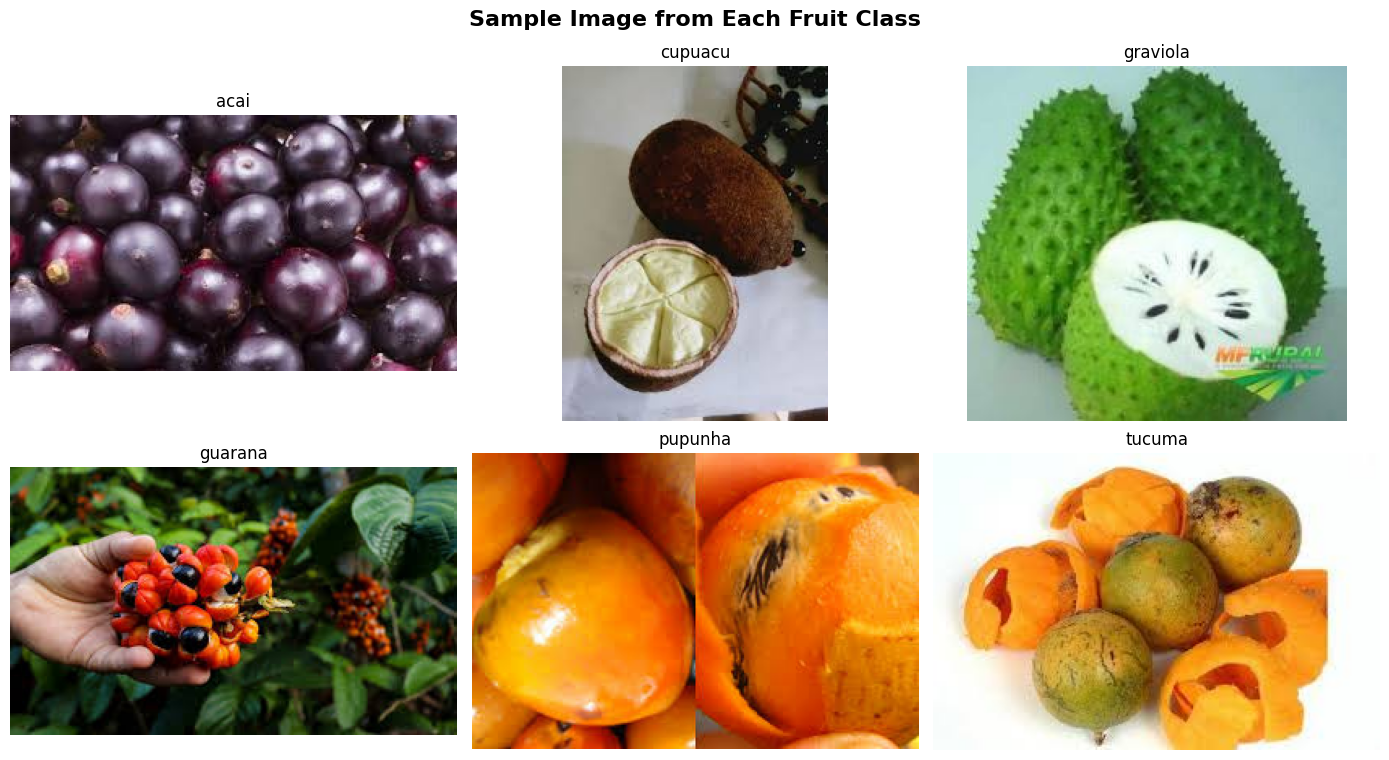


Observations:
- The dataset contains 6 Amazonian fruit classes: acai, cupuacu, graviola, guarana, pupunha, tucuma.
- Images vary in size, background, and lighting conditions.
- Some classes (e.g. pupunha) show clusters of fruit, while others show individual fruits.
- Preprocessing (resize + normalise) is essential before training.


In [10]:
import random
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

# Get all class directories from the train folder
class_dirs = sorted(os.listdir(train_dir))
num_classes = len(class_dirs)
print(f'Number of classes: {num_classes}')
print(f'Classes          : {class_dirs}')

# Select one random image per class
random.seed(42)
sample_images = []
sample_labels = []

for cls in class_dirs:
    cls_path = os.path.join(train_dir, cls)
    images   = [f for f in os.listdir(cls_path)
                if f.lower().endswith(('.jpeg', '.jpg', '.png'))]
    chosen   = random.choice(images)
    sample_images.append(os.path.join(cls_path, chosen))
    sample_labels.append(cls)

# Display in a 2-row grid
cols = 3
rows = 2
fig, axes = plt.subplots(rows, cols, figsize=(14, 8))
fig.suptitle('Sample Image from Each Fruit Class', fontsize=16, fontweight='bold')

for idx, (img_path, label) in enumerate(zip(sample_images, sample_labels)):
    ax = axes[idx // cols][idx % cols]
    img = mpimg.imread(img_path)
    ax.imshow(img)
    ax.set_title(label, fontsize=12)
    ax.axis('off')

plt.tight_layout()
plt.show()

print('\nObservations:')
print('- The dataset contains 6 Amazonian fruit classes: acai, cupuacu, graviola, guarana, pupunha, tucuma.')
print('- Images vary in size, background, and lighting conditions.')
print('- Some classes (e.g. pupunha) show clusters of fruit, while others show individual fruits.')
print('- Preprocessing (resize + normalise) is essential before training.')

### 1.2 Check for Corrupted Images

In [11]:
from PIL import Image

corrupted_images = []

for cls in os.listdir(train_dir):
    cls_path = os.path.join(train_dir, cls)
    if not os.path.isdir(cls_path):
        continue
    for fname in os.listdir(cls_path):
        img_path = os.path.join(cls_path, fname)
        try:
            with Image.open(img_path) as img:
                img.verify()          # Verify integrity without fully decoding
        except (IOError, SyntaxError):
            corrupted_images.append(img_path)
            os.remove(img_path)
            print(f'Removed corrupted image: {img_path}')

if not corrupted_images:
    print('No corrupted images found.')
else:
    print(f'\nTotal corrupted images removed: {len(corrupted_images)}')

No corrupted images found.


---
## Task 2 – Loading and Preprocessing Image Data

In [12]:
import tensorflow as tf
import numpy as np

print('TensorFlow version:', tf.__version__)

# Hyper-parameters
IMG_HEIGHT       = 128
IMG_WIDTH        = 128
BATCH_SIZE       = 16
VALIDATION_SPLIT = 0.2
SEED             = 123

rescale = tf.keras.layers.Rescaling(1.0 / 255)

# ── Training dataset ──────────────────────────────────────────
train_ds_raw = tf.keras.preprocessing.image_dataset_from_directory(
    train_dir,
    labels           = 'inferred',
    label_mode       = 'int',
    image_size       = (IMG_HEIGHT, IMG_WIDTH),
    interpolation    = 'nearest',
    batch_size       = BATCH_SIZE,
    shuffle          = True,
    validation_split = VALIDATION_SPLIT,
    subset           = 'training',
    seed             = SEED
)

# ✅ Save class_names BEFORE .map()
class_names = train_ds_raw.class_names
num_classes = len(class_names)

train_ds = train_ds_raw.map(lambda x, y: (rescale(x), y))

# ── Validation dataset ────────────────────────────────────────
val_ds = tf.keras.preprocessing.image_dataset_from_directory(
    train_dir,
    labels           = 'inferred',
    label_mode       = 'int',
    image_size       = (IMG_HEIGHT, IMG_WIDTH),
    interpolation    = 'nearest',
    batch_size       = BATCH_SIZE,
    shuffle          = False,
    validation_split = VALIDATION_SPLIT,
    subset           = 'validation',
    seed             = SEED
).map(lambda x, y: (rescale(x), y))

# ── Test dataset ──────────────────────────────────────────────
test_ds = tf.keras.preprocessing.image_dataset_from_directory(
    test_dir,
    labels        = 'inferred',
    label_mode    = 'int',
    image_size    = (IMG_HEIGHT, IMG_WIDTH),
    interpolation = 'nearest',
    batch_size    = BATCH_SIZE,
    shuffle       = False
).map(lambda x, y: (rescale(x), y))

print(f'\nClass names : {class_names}')
print(f'Num classes : {num_classes}')

TensorFlow version: 2.20.0
Found 90 files belonging to 6 classes.
Using 72 files for training.
Found 90 files belonging to 6 classes.
Using 18 files for validation.
Found 30 files belonging to 6 classes.

Class names : ['acai', 'cupuacu', 'graviola', 'guarana', 'pupunha', 'tucuma']
Num classes : 6


---
## Task 3 – Build the CNN Model

In [13]:
from tensorflow.keras import layers, models

def build_cnn(input_shape, num_classes):
    """Build the CNN as specified in Worksheet-5 Task 3."""
    model = models.Sequential([

        # ── Convolutional Block 1 ──────────────────────────────────────────
        layers.Conv2D(
            filters     = 32,
            kernel_size = (3, 3),
            strides     = (1, 1),
            padding     = 'same',
            activation  = 'relu',
            input_shape = input_shape,
            name        = 'conv2d_1'
        ),
        layers.MaxPooling2D(
            pool_size = (2, 2),
            strides   = (2, 2),
            name      = 'maxpool_1'
        ),

        # ── Convolutional Block 2 ──────────────────────────────────────────
        layers.Conv2D(
            filters     = 32,
            kernel_size = (3, 3),
            strides     = (1, 1),
            padding     = 'same',
            activation  = 'relu',
            name        = 'conv2d_2'
        ),
        layers.MaxPooling2D(
            pool_size = (2, 2),
            strides   = (2, 2),
            name      = 'maxpool_2'
        ),

        # ── Fully Connected Network ────────────────────────────────────────
        layers.Flatten(name='flatten'),

        layers.Dense(128, activation='relu', name='hidden_1'),
        layers.Dense(64,  activation='relu', name='hidden_2'),

        layers.Dense(num_classes, activation='softmax', name='output')
    ])
    return model


model = build_cnn(
    input_shape = (IMG_HEIGHT, IMG_WIDTH, 3),
    num_classes = num_classes
)

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_1 (Conv2D)               │ (None, 128, 128, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ maxpool_1 (MaxPooling2D)        │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 64, 64, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ maxpool_2 (MaxPooling2D)        │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 32768)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ hidden_1 (Dense)                │ (None, 128)            │     4,194,432 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ hidden_2 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (None, 6)              │           390 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,213,222 (16.07 MB)

 Trainable params: 4,213,222 (16.07 MB)

 Non-trainable params: 0 (0.00 B)

---
## Task 4 – Compile and Train the Model

In [14]:
# ── Compile ───────────────────────────────────────────────────────────────────
model.compile(
    optimizer = 'adam',
    loss      = 'sparse_categorical_crossentropy',
    metrics   = ['accuracy']
)

# ── Callbacks ─────────────────────────────────────────────────────────────────
checkpoint_cb = tf.keras.callbacks.ModelCheckpoint(
    filepath          = 'best_fruit_cnn.h5',
    monitor           = 'val_accuracy',
    save_best_only    = True,
    verbose           = 1
)

early_stop_cb = tf.keras.callbacks.EarlyStopping(
    monitor              = 'val_loss',
    patience             = 20,          # Stop if val_loss doesn't improve for 20 epochs
    restore_best_weights = True,
    verbose              = 1
)

# ── Train ─────────────────────────────────────────────────────────────────────
EPOCHS = 250

history = model.fit(
    train_ds,
    epochs          = EPOCHS,
    validation_data = val_ds,
    callbacks       = [checkpoint_cb, early_stop_cb],
    verbose         = 1
)

print('\nTraining complete.')

Epoch 1/250
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 263ms/step - accuracy: 0.1740 - loss: 2.1727
Epoch 1: val_accuracy improved from None to 0.05556, saving model to best_fruit_cnn.h5



Epoch 1: finished saving model to best_fruit_cnn.h5
5/5 ━━━━━━━━━━━━━━━━━━━━ 4s 395ms/step - accuracy: 0.1667 - loss: 2.2145 - val_accuracy: 0.0556 - val_loss: 1.9783
Epoch 2/250
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 273ms/step - accuracy: 0.4399 - loss: 1.7441
Epoch 2: val_accuracy improved from 0.05556 to 0.11111, saving model to best_fruit_cnn.h5



Epoch 2: finished saving model to best_fruit_cnn.h5
5/5 ━━━━━━━━━━━━━━━━━━━━ 2s 402ms/step - accuracy: 0.4028 - loss: 1.7079 - val_accuracy: 0.1111 - val_loss: 1.7639
Epoch 3/250
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 571ms/step - accuracy: 0.3802 - loss: 1.4903
Epoch 3: val_accuracy improved from 0.11111 to 0.66667, saving model to best_fruit_cnn.h5



Epoch 3: finished saving model to best_fruit_cnn.h5
5/5 ━━━━━━━━━━━━━━━━━━━━ 4s 835ms/step - accuracy: 0.4583 - loss: 1.4052 - val_accuracy: 0.6667 - val_loss: 1.3401
Epoch 4/250
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 412ms/step - accuracy: 0.6840 - loss: 1.0255
Epoch 4: val_accuracy did not improve from 0.66667
5/5 ━━━━━━━━━━━━━━━━━━━━ 3s 496ms/step - accuracy: 0.6806 - loss: 0.9986 - val_accuracy: 0.5556 - val_loss: 0.9144
Epoch 5/250
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 263ms/step - accuracy: 0.8635 - loss: 0.6221
Epoch 5: val_accuracy improved from 0.66667 to 0.83333, saving model to best_fruit_cnn.h5



Epoch 5: finished saving model to best_fruit_cnn.h5
5/5 ━━━━━━━━━━━━━━━━━━━━ 2s 351ms/step - accuracy: 0.8333 - loss: 0.6327 - val_accuracy: 0.8333 - val_loss: 0.9385
Epoch 6/250
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 265ms/step - accuracy: 0.9615 - loss: 0.4260
Epoch 6: val_accuracy did not improve from 0.83333
5/5 ━━━━━━━━━━━━━━━━━━━━ 2s 314ms/step - accuracy: 0.9583 - loss: 0.3590 - val_accuracy: 0.8333 - val_loss: 0.5220
Epoch 7/250
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 257ms/step - accuracy: 0.9899 - loss: 0.1604
Epoch 7: val_accuracy improved from 0.83333 to 0.88889, saving model to best_fruit_cnn.h5



Epoch 7: finished saving model to best_fruit_cnn.h5
5/5 ━━━━━━━━━━━━━━━━━━━━ 2s 341ms/step - accuracy: 0.9861 - loss: 0.1638 - val_accuracy: 0.8889 - val_loss: 0.3527
Epoch 8/250
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 279ms/step - accuracy: 0.9899 - loss: 0.1043
Epoch 8: val_accuracy did not improve from 0.88889
5/5 ━━━━━━━━━━━━━━━━━━━━ 2s 365ms/step - accuracy: 0.9861 - loss: 0.1022 - val_accuracy: 0.8889 - val_loss: 0.3885
Epoch 9/250
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 445ms/step - accuracy: 1.0000 - loss: 0.0576
Epoch 9: val_accuracy did not improve from 0.88889
5/5 ━━━━━━━━━━━━━━━━━━━━ 3s 527ms/step - accuracy: 1.0000 - loss: 0.0660 - val_accuracy: 0.8333 - val_loss: 0.4682
Epoch 10/250
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 330ms/step - accuracy: 1.0000 - loss: 0.0546
Epoch 10: val_accuracy did not improve from 0.88889
5/5 ━━━━━━━━━━━━━━━━━━━━ 3s 415ms/step - accuracy: 1.0000 - loss: 0.0451 - val_accuracy: 0.8889 - val_loss: 0.3810
Epoch 11/250
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 269ms/step - accuracy: 1.0000 - loss

### Training & Validation Curves

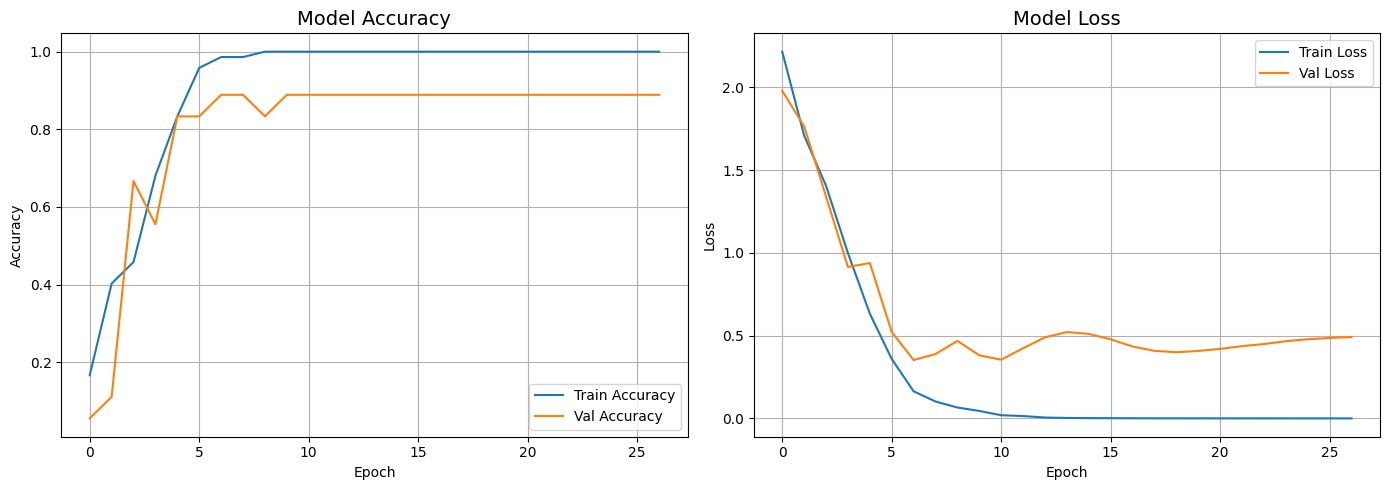

Curves saved to training_curves.png


In [15]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Accuracy
axes[0].plot(history.history['accuracy'],     label='Train Accuracy')
axes[0].plot(history.history['val_accuracy'], label='Val Accuracy')
axes[0].set_title('Model Accuracy', fontsize=14)
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Accuracy')
axes[0].legend()
axes[0].grid(True)

# Loss
axes[1].plot(history.history['loss'],     label='Train Loss')
axes[1].plot(history.history['val_loss'], label='Val Loss')
axes[1].set_title('Model Loss', fontsize=14)
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.savefig('training_curves.png', dpi=150)
plt.show()
print('Curves saved to training_curves.png')

---
## Task 5 – Evaluate the Model

In [16]:
test_loss, test_acc = model.evaluate(test_ds, verbose=1)
print(f'\nTest Loss     : {test_loss:.4f}')
print(f'Test Accuracy : {test_acc:.4f}  ({test_acc*100:.2f}%)')

2/2 ━━━━━━━━━━━━━━━━━━━━ 13s 5s/step - accuracy: 0.6333 - loss: 0.9683

Test Loss     : 0.9683
Test Accuracy : 0.6333  (63.33%)


---
## Task 6 – Save and Reload the Model

In [17]:
# ── Save the final model ──────────────────────────────────────────────────────
model.save('fruit_cnn_final.h5')
print('Model saved to fruit_cnn_final.h5')

# ── Load and re-evaluate ──────────────────────────────────────────────────────
loaded_model = tf.keras.models.load_model('fruit_cnn_final.h5')
print('\nLoaded model summary:')
loaded_model.summary()

loaded_loss, loaded_acc = loaded_model.evaluate(test_ds, verbose=1)
print(f'\nLoaded Model – Test Loss     : {loaded_loss:.4f}')
print(f'Loaded Model – Test Accuracy : {loaded_acc:.4f}  ({loaded_acc*100:.2f}%)')

Model saved to fruit_cnn_final.h5



Loaded model summary:


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_1 (Conv2D)               │ (None, 128, 128, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ maxpool_1 (MaxPooling2D)        │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 64, 64, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ maxpool_2 (MaxPooling2D)        │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 32768)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ hidden_1 (Dense)                │ (None, 128)            │     4,194,432 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ hidden_2 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (None, 6)              │           390 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,213,224 (16.07 MB)

 Trainable params: 4,213,222 (16.07 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 2 (12.00 B)

2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 118ms/step - accuracy: 0.6333 - loss: 0.9683

Loaded Model – Test Loss     : 0.9683
Loaded Model – Test Accuracy : 0.6333  (63.33%)


---
## Task 7 – Predictions and Classification Report

In [18]:
from sklearn.metrics import classification_report

# Collect all true labels and predictions from the test set
y_true, y_pred_prob = [], []

for images, labels in test_ds:
    preds = loaded_model.predict(images, verbose=0)
    y_true.extend(labels.numpy())
    y_pred_prob.extend(preds)

y_true      = np.array(y_true)
y_pred_prob = np.array(y_pred_prob)
y_pred      = np.argmax(y_pred_prob, axis=1)   # Convert probabilities → class indices

# ── Classification Report ─────────────────────────────────────────────────────
print('\nClassification Report:')
print('=' * 60)
report = classification_report(
    y_true, y_pred,
    target_names = class_names
)
print(report)


Classification Report:
              precision    recall  f1-score   support

        acai       0.62      1.00      0.77         5
     cupuacu       0.67      0.80      0.73         5
    graviola       0.75      0.60      0.67         5
     guarana       0.56      1.00      0.71         5
     pupunha       0.00      0.00      0.00         5
      tucuma       0.67      0.40      0.50         5

    accuracy                           0.63        30
   macro avg       0.54      0.63      0.56        30
weighted avg       0.54      0.63      0.56        30



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


### Visualise Sample Predictions

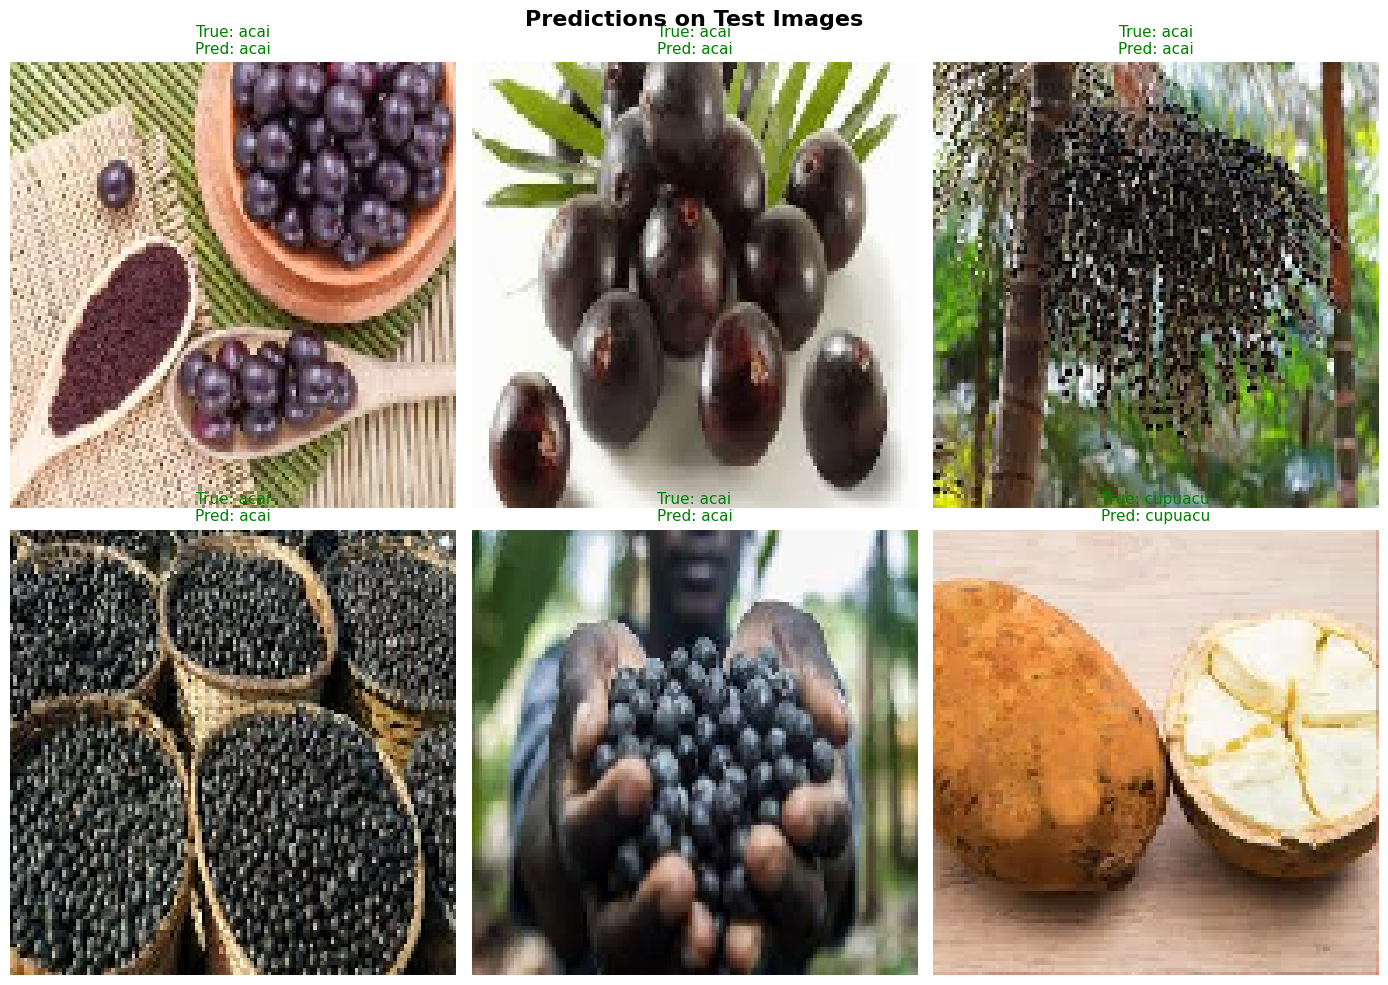

Sample predictions saved to sample_predictions.png


In [19]:
# Show 6 test images with predicted and true labels
sample_images_test, sample_labels_test = next(iter(test_ds))
sample_preds = loaded_model.predict(sample_images_test, verbose=0)
sample_pred_labels = np.argmax(sample_preds, axis=1)

n_show = min(6, len(sample_images_test))
cols = 3
rows = (n_show + cols - 1) // cols

fig, axes = plt.subplots(rows, cols, figsize=(14, 5 * rows))
fig.suptitle('Predictions on Test Images', fontsize=16, fontweight='bold')

axes = axes.flatten()
for i in range(n_show):
    img = sample_images_test[i].numpy()
    true_label = class_names[sample_labels_test[i]]
    pred_label = class_names[sample_pred_labels[i]]
    color = 'green' if true_label == pred_label else 'red'
    axes[i].imshow(img)
    axes[i].set_title(
        f'True: {true_label}\nPred: {pred_label}',
        color=color, fontsize=11
    )
    axes[i].axis('off')

# Hide unused axes
for j in range(n_show, len(axes)):
    axes[j].axis('off')

plt.tight_layout()
plt.savefig('sample_predictions.png', dpi=150)
plt.show()
print('Sample predictions saved to sample_predictions.png')